# Round 004 — ตระกูล D: การสร้างพอร์ต

**ทำอะไร:** เปลี่ยนวิธีจัดพอร์ต (น้ำหนัก, ความถี่, จำกัด sector, ลด turnover) ทีละมิติบนฐาน 2 ตัวที่เลือกด้วยกฎประกาศล่วงหน้า

**อุปมา:** ใช้วัตถุดิบเดิม แต่ลองเปลี่ยนวิธีจัดจาน — ถ้าจานอร่อยขึ้นเพราะวิธีจัดล้วน ๆ ก็ยังต้องพิสูจน์ว่าไม่ได้บังเอิญ (S3)

**อ่านผลอย่างไร:** สเปกใน rounds/round_004/HYPOTHESIS.md

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_004/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r004_Q_LOWACC_overall_W_IV,0.842,0.640,0.681,0.169,0.125,-0.355,-0.376,True,True,1.000,0.645,63.250,51,0.906,1.137
1,r004_Q_LOWACC_overall_W_CAP,0.929,0.640,0.681,0.190,0.125,-0.286,-0.376,True,True,0.946,0.189,63.250,51,1.020,1.137
2,r004_Q_LOWACC_overall_F1,0.837,0.625,0.681,0.185,0.123,-0.386,-0.377,True,False,1.000,0.687,63.750,51,0.770,1.123
3,r004_Q_LOWACC_overall_F2,0.826,0.625,0.681,0.188,0.124,-0.386,-0.377,False,False,1.000,0.623,64.125,51,0.885,1.108
4,r004_Q_LOWACC_overall_SECCAP,0.863,0.640,0.681,0.186,0.125,-0.362,-0.376,True,True,1.000,0.672,63.250,51,0.787,1.137
5,r004_Q_LOWACC_overall_BUFFER,0.872,0.640,0.681,0.190,0.125,-0.347,-0.376,True,True,1.000,0.674,63.250,51,0.780,1.137
6,r004_C_SHYQMOM_overall_W_IV,0.780,0.614,0.681,0.143,0.122,-0.344,-0.384,False,False,0.703,0.046,64.340,51,1.314,1.093
7,r004_C_SHYQMOM_overall_W_CAP,0.923,0.614,0.681,0.178,0.122,-0.300,-0.384,True,True,0.973,0.125,64.340,51,1.219,1.093
8,r004_C_SHYQMOM_overall_F1,0.707,0.625,0.681,0.135,0.124,-0.371,-0.377,False,False,0.649,0.029,64.167,51,1.088,1.108
9,r004_C_SHYQMOM_overall_F2,0.666,0.640,0.681,0.128,0.125,-0.347,-0.376,False,False,0.649,0.011,63.417,51,1.139,1.137


ผู้เข้ารอบ (S1+S2+S3+S6): []


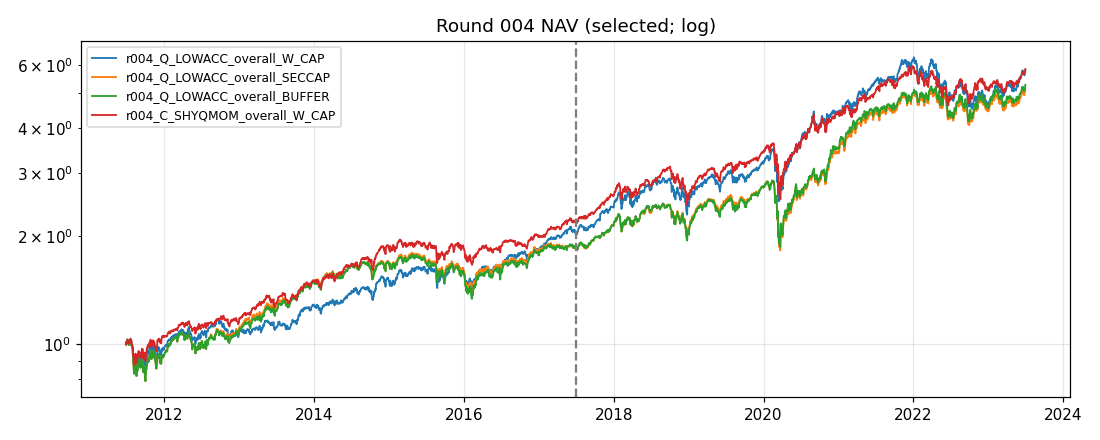

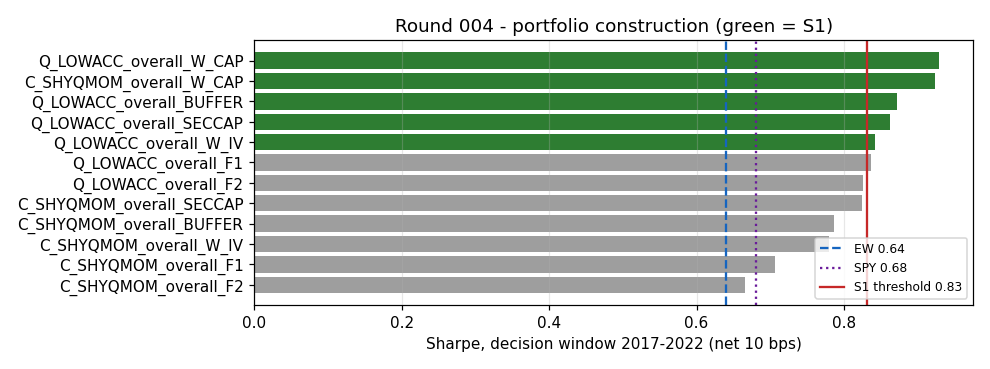

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_004_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_004/RESULTS.md").read_text()))

# Round 004 — ผล (ตระกูล D: การสร้างพอร์ต) — **ไม่มีผู้เข้ารอบ**

- trial รอบนี้ 12 → สะสม **85**; ฐาน (กฎประกาศล่วงหน้า) = `r001_Q_LOWACC_overall`, `r003_C_SHYQMOM_overall`
- ⚠️ ฐานถูกเลือกจากผลก่อนหน้า → S3 (N สะสม) คือด่านที่ลงโทษการค้นหานี้

| ผลสำคัญ | ตัวเลข |
|---|---|
| ผ่าน S1 (10 และ 25 bps) | 5 variant: Q_LOWACC W_IV (0.842), W_CAP (0.929), SECCAP (0.863), BUFFER (0.872); SHYQMOM W_CAP (0.923) |
| ผ่าน S1 ที่ 10 bps แต่ตกที่ 25 bps | Q_LOWACC F1 (ครึ่งปี, 0.837) |
| **S3 (DSR) ของทุกตัว** | **0.011–0.687 < 0.95 → ไม่มีผู้เข้ารอบ** |
| cap-weighted | Sharpe สูงสุด (0.923–0.929) แต่ DSR ต่ำ (0.125–0.189) — ส่วนเกินเทียบ EW ส่วนใหญ่มาจากการถือหุ้นใหญ่ (mega-cap) ที่นำตลาดช่วง 2017–2022 ไม่ใช่จากสัญญาณ |
| ช่วงประกอบ 2011–2016 ของฐาน Q_LOWACC | ทุก variant แพ้ EW (Sharpe 0.770–1.020 vs 1.108–1.137) |
| SHYQMOM ที่ความถี่ต่ำลง (Q, A) | Sharpe ลดลง (0.707, 0.666) |

## การตีความ
- การปรับการสร้างพอร์ตทำให้ "ผ่าน S1" ได้ง่ายขึ้น แต่ไม่มีตัวไหนผ่านการปรับ multiple testing (S3) — และยิ่งค้นหา N ยิ่งโต เกณฑ์ยิ่งเข้ม
- สัญญาณ accruals ต่ำ ยังคงแพ้ EW ในช่วงประกอบ ทุกรูปแบบ → ความได้เปรียบผูกกับช่วงเวลา 2017–2022
- ไม่มีการลดเกณฑ์ — ไปต่อตระกูล E
